# Clustering of Superconductor data

In [8]:
from __future__ import print_function, division   
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.metrics import mean_absolute_error, r2_score, roc_auc_score

import lightgbm as lgb 
from scipy.stats import randint, poisson
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA

from sklearn.metrics import mean_squared_error, log_loss
from lightgbm import early_stopping
import time

SavePlots = False


import amasF as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

from iminuit.cost import UnbinnedNLL
from iminuit import Minuit, cost

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 16,
    "axes.grid": True,
    "grid.alpha": 0.2
})

In [17]:
data_SC = pd.read_csv('Supplementary_1/SuperCon_features.csv')
data_MP = pd.read_csv('Supplementary_1/Materials_Project_features.csv')

tc_SC = np.load('Supplementary_1/SuperCon_critical_temperatures.npy')
chem_MP = np.load('Supplementary_1/Materials_Project_chemical_compositions.npy')
chem_SC = np.load('Supplementary_1/SuperCon_chemical_compositions.npy', allow_pickle=True)

## Overview of correlations

<Axes: >

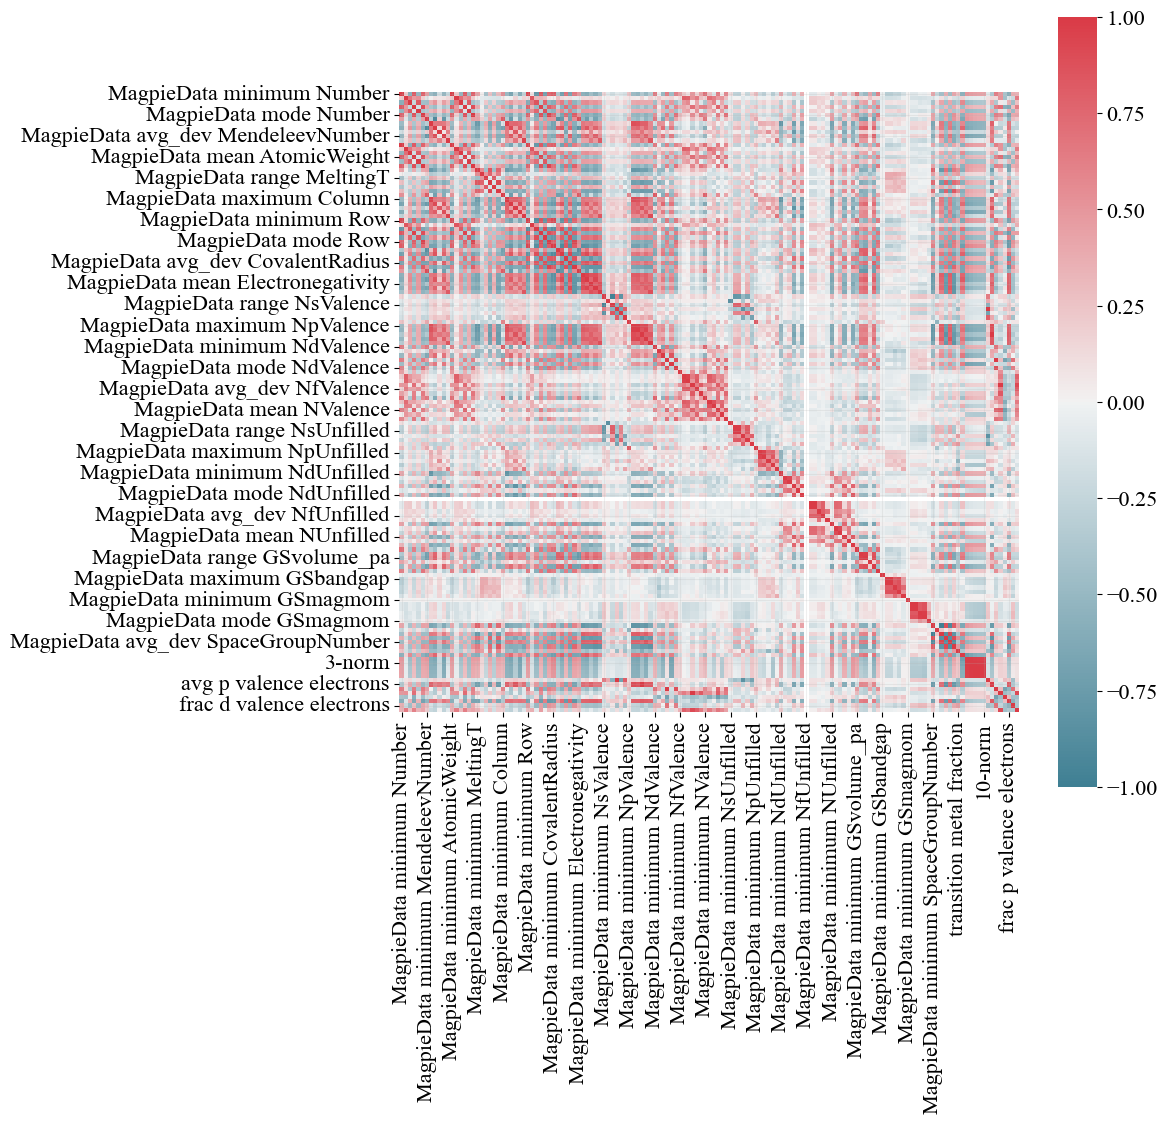

In [18]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(data_SC.corr(), mask=np.zeros_like(data_SC.corr(), dtype=np.bool),
            cmap=sns.diverging_palette(220, 10, as_cmap=True), vmin=-1.0, vmax=1.0,
            square=True)

In [ ]:
import optuna
import umap
from sklearn.metrics import silhouette_score

feature_names = data_SC.columns.tolist()  # your 147 features
data_array = data_SC.values

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def objective(trial):
    # First decide how many features to use
    n_features = trial.suggest_int("n_features", 5, 50)
    
    # Then select exactly that many by ranking random weights
    weights = [trial.suggest_float(f"w_{i}", 0.0, 1.0) for i in range(len(feature_names))]
    selected = sorted(range(len(feature_names)), key=lambda i: -weights[i])[:n_features]
    
    X = data_array[:, selected]
    
    reducer = umap.UMAP(
        n_neighbors=103,
        min_dist=0.5,
        n_components=2,
        random_state=42
    )
    embedding = reducer.fit_transform(X)
    
    n_clusters = trial.suggest_int("n_clusters", 2, 10)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embedding)
    
    score = silhouette_score(embedding, cluster_labels, sample_size=5000, random_state=42)
    return score

study_features = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_features.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-05-25 13:54:17,615] A new study created in memory with name: no-name-5bdecdb5-ab6a-420a-8412-13877aac45ee
  0%|          | 0/50 [00:00<?, ?it/s]/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Best trial: 0. Best value: 0.355289:   2%|▏         | 1/50 [00:11<09:05, 11.13s/it]/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-25 13:54:28,750] Trial 0 finished with value: 0.3552890717983246 and parameters: {'n_features': 22, 'w_0': 0.9507143064099162, 'w_1': 0.7319939418114051, 'w_2': 0.5986584841970366, 'w_3': 0.15601864044243652, 'w_4': 0.15599452033620265, 'w_5': 0.05808361216819946, 'w_6': 0.8661761457749352, 'w_7': 0.6011150117432088, 'w_8': 0.7080725777960455, 'w_9': 0.020584494295802447, 'w_10': 0.9699098521619943, 'w_11': 0.8324426408004217, 'w_12': 0.21233911067827616, 'w_13': 0.18182496720710062, 'w_14': 0.18340450985343382, 'w_15': 0.3042422429595377, 'w_16': 0.5247564316322378, 'w_17': 0.43194501864211576, 'w_18': 0.2912291401980419, 'w_19': 0.6118528947223795, 'w_20': 0.13949386065204183, 'w_21': 0.29214464853521815, 'w_22': 0.3663618432936917, 'w_23': 0.45606998421703593, 'w_24': 0.7851759613930136, 'w_25': 0.19967378215835974, 'w_26': 0.5142344384136116, 'w_27': 0.5924145688620425, 'w_28': 0.046450412719997725, 'w_29': 0.6075448519014384, 'w_30': 0.17052412368729153, 'w_31': 0.06505

Best trial: 1. Best value: 0.476731:   4%|▍         | 2/50 [00:23<09:21, 11.70s/it]/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-25 13:54:40,840] Trial 1 finished with value: 0.47673094272613525 and parameters: {'n_features': 17, 'w_0': 0.9082658859666537, 'w_1': 0.23956189066697242, 'w_2': 0.1448948720912231, 'w_3': 0.489452760277563, 'w_4': 0.9856504541106007, 'w_5': 0.2420552715115004, 'w_6': 0.6721355474058786, 'w_7': 0.7616196153287176, 'w_8': 0.23763754399239967, 'w_9': 0.7282163486118596, 'w_10': 0.3677831327192532, 'w_11': 0.6323058305935795, 'w_12': 0.6335297107608947, 'w_13': 0.5357746840747585, 'w_14': 0.0902897700544083, 'w_15': 0.835302495589238, 'w_16': 0.32078006497173583, 'w_17': 0.18651851039985423, 'w_18': 0.040775141554763916, 'w_19': 0.5908929431882418, 'w_20': 0.6775643618422824, 'w_21': 0.016587828927856152, 'w_22': 0.512093058299281, 'w_23': 0.22649577519793795, 'w_24': 0.6451727904094499, 'w_25': 0.17436642900499144, 'w_26': 0.690937738102466, 'w_27': 0.3867353463005374, 'w_28': 0.9367299887367345, 'w_29': 0.13752094414599325, 'w_30': 0.3410663510502585, 'w_31': 0.1134735212405

Best trial: 1. Best value: 0.476731:   6%|▌         | 3/50 [00:34<08:57, 11.44s/it]/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

Best trial: 30. Best value: 0.487959:  98%|█████████▊| 49/50 [09:42<00:11, 11.63s/it]/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-25 14:04:00,191] Trial 48 finished with value: 0.4461763799190521 and parameters: {'n_features': 41, 'w_0': 0.9519210679210424, 'w_1': 0.30698454179634876, 'w_2': 0.20435199381395475, 'w_3': 0.5792150445570609, 'w_4': 0.2625936692852331, 'w_5': 0.05494143575762539, 'w_6': 0.5275742026045721, 'w_7': 0.5644845642556614, 'w_8': 0.47477592883562736, 'w_9': 0.6162309688758019, 'w_10': 0.665923295566264, 'w_11': 0.7155593725814404, 'w_12': 0.31435307246869454, 'w_13': 0.30965991296562156, 'w_14': 0.5106479742406442, 'w_15': 0.7549337063114316, 'w_16': 0.4494088466236128, 'w_17': 0.7720685457069472, 'w_18': 0.04510042239202754, 'w_19': 0.6147189098117208, 'w_20': 0.6729670773636511, 'w_21': 0.25503663111320307, 'w_22': 0.8291204914096877, 'w_23': 0.6174439689083109, 'w_24': 0.5885364344342152, 'w_25': 0.06403779766591824, 'w_26': 0.19496357094748618, 'w_27': 0.4987258548645676, 'w_28': 0.8958284686610921, 'w_29': 0.05130842493930354, 'w_30': 0.38859408181459687, 'w_31': 0.445611326

Best trial: 30. Best value: 0.487959: 100%|██████████| 50/50 [09:54<00:00, 11.88s/it]

[I 2026-05-25 14:04:11,672] Trial 49 finished with value: 0.4548942744731903 and parameters: {'n_features': 37, 'w_0': 0.7214433957864016, 'w_1': 0.4640981158994594, 'w_2': 0.289158884645069, 'w_3': 0.5023939806811952, 'w_4': 0.8731967511341028, 'w_5': 0.2485024064179739, 'w_6': 0.43845057051880487, 'w_7': 0.7806796143476994, 'w_8': 0.5901248690942646, 'w_9': 0.25469519079095293, 'w_10': 0.5853764425355334, 'w_11': 0.6149755308308033, 'w_12': 0.1742857151682884, 'w_13': 0.461535343468684, 'w_14': 0.42889882680661295, 'w_15': 0.5906858971990602, 'w_16': 0.3991015989029211, 'w_17': 0.5744220078149959, 'w_18': 0.29897550327711625, 'w_19': 0.3502763901821743, 'w_20': 0.1663261498576179, 'w_21': 0.1458551111531572, 'w_22': 0.9526038346632026, 'w_23': 0.36740615257729586, 'w_24': 0.6845600052634712, 'w_25': 0.49714326835300127, 'w_26': 0.3775035917794165, 'w_27': 0.4355320760447363, 'w_28': 0.7549660667668158, 'w_29': 0.6256692956764537, 'w_30': 0.04418303894611175, 'w_31': 0.722054943458265

KeyError: 'feature_0'

In [31]:
best_trial = study_features.best_trial

n_features = best_trial.params["n_features"]
weights = [best_trial.params[f"w_{i}"] for i in range(len(feature_names))]
selected_indices = sorted(range(len(feature_names)), key=lambda i: -weights[i])[:n_features]

selected_features = [feature_names[i] for i in selected_indices]

print(f"Selected {len(selected_features)} features:")
print(selected_features)

Selected 31 features:
['MagpieData avg_dev Column', 'MagpieData minimum NfValence', 'MagpieData mean CovalentRadius', 'MagpieData mean NfValence', 'MagpieData maximum NfUnfilled', 'MagpieData range GSmagmom', 'MagpieData maximum SpaceGroupNumber', '2-norm', 'MagpieData mean Row', 'MagpieData minimum Electronegativity', 'MagpieData maximum NUnfilled', 'MagpieData avg_dev MendeleevNumber', 'MagpieData avg_dev MeltingT', 'MagpieData minimum MendeleevNumber', 'MagpieData mode NUnfilled', 'MagpieData range NpUnfilled', 'MagpieData range MeltingT', 'MagpieData minimum NdUnfilled', 'MagpieData avg_dev Number', 'MagpieData avg_dev NValence', 'MagpieData minimum CovalentRadius', 'MagpieData maximum NdValence', 'MagpieData range Row', 'MagpieData minimum Number', 'MagpieData range Number', 'MagpieData maximum NdUnfilled', 'MagpieData mode GSvolume_pa', 'MagpieData mode MendeleevNumber', 'MagpieData maximum NpUnfilled', 'MagpieData maximum Electronegativity', 'MagpieData mode GSmagmom']


<Axes: >

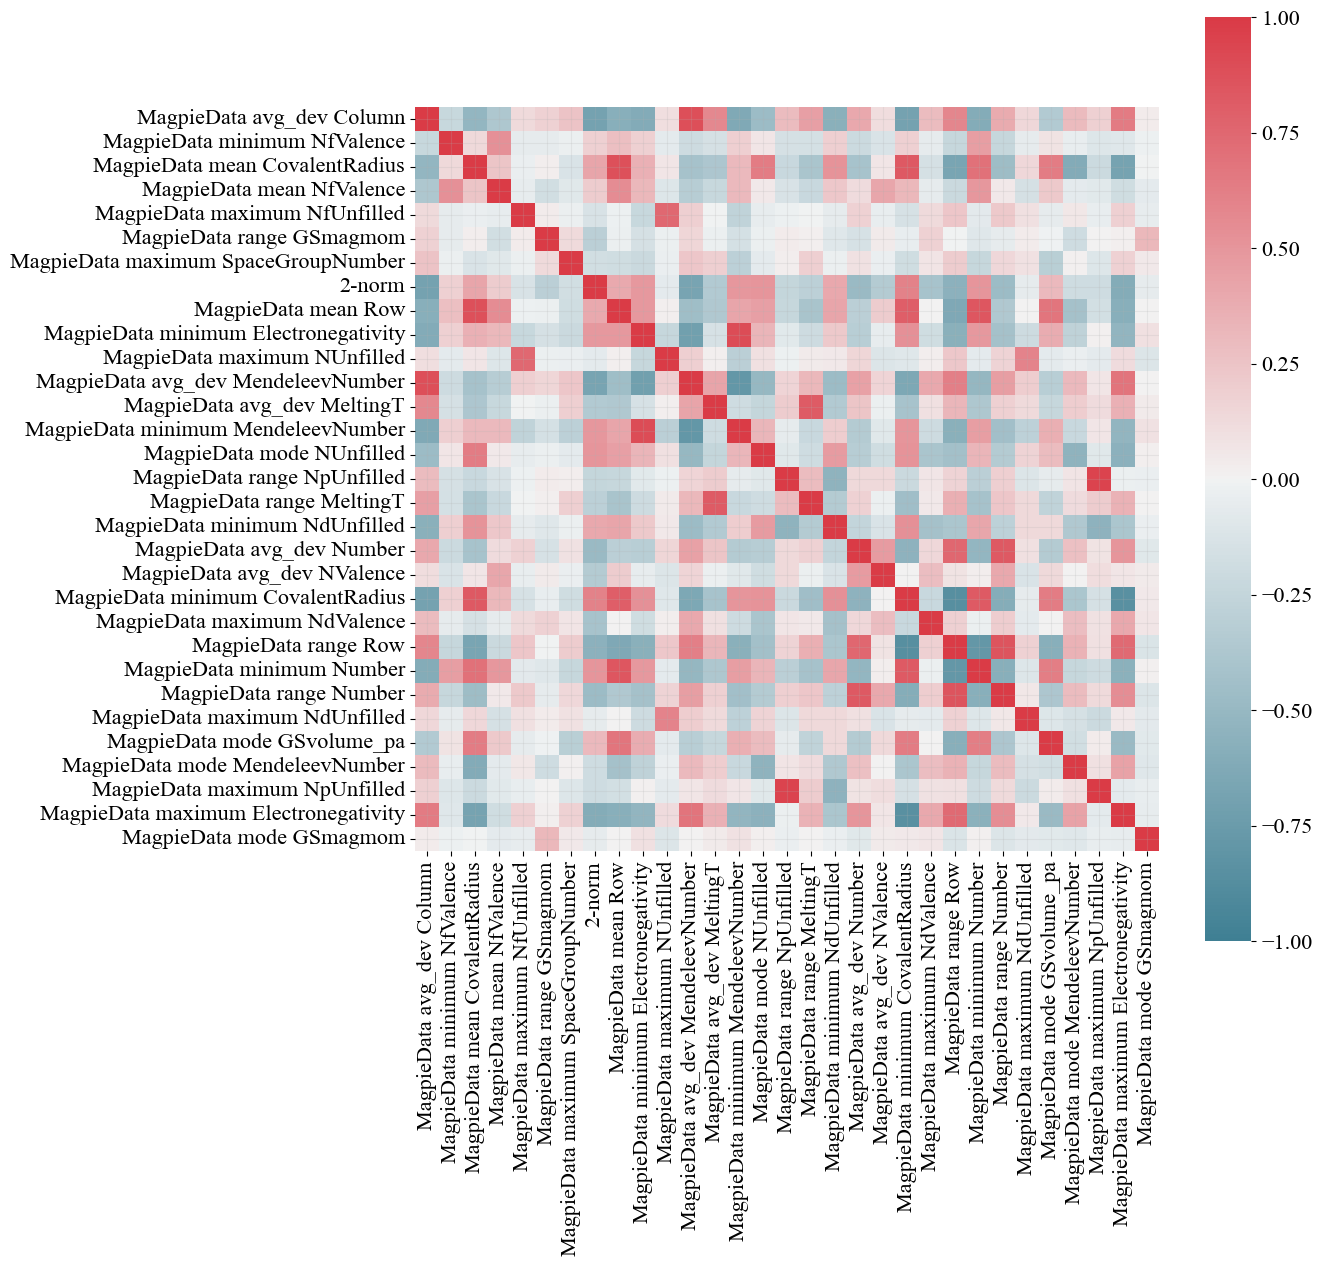

In [33]:
data_SC_red = data_SC[selected_features]
data_MP_red = data_MP[selected_features]

plt.figure(figsize=(12,12))
sns.heatmap(data_SC_red.corr(), mask=np.zeros_like(data_SC_red.corr(), dtype=np.bool),
            cmap=sns.diverging_palette(220, 10, as_cmap=True), vmin=-1.0, vmax=1.0,
            square=True)

In [34]:
reducer = umap.UMAP(n_neighbors=103, min_dist=0.5, n_components=2, random_state=42)
emb_SC_opt = reducer.fit_transform(data_SC_red)
emb_MP_opt = reducer.transform(data_MP_red)

/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0, 0.5, 'UMAP Dimension 2')

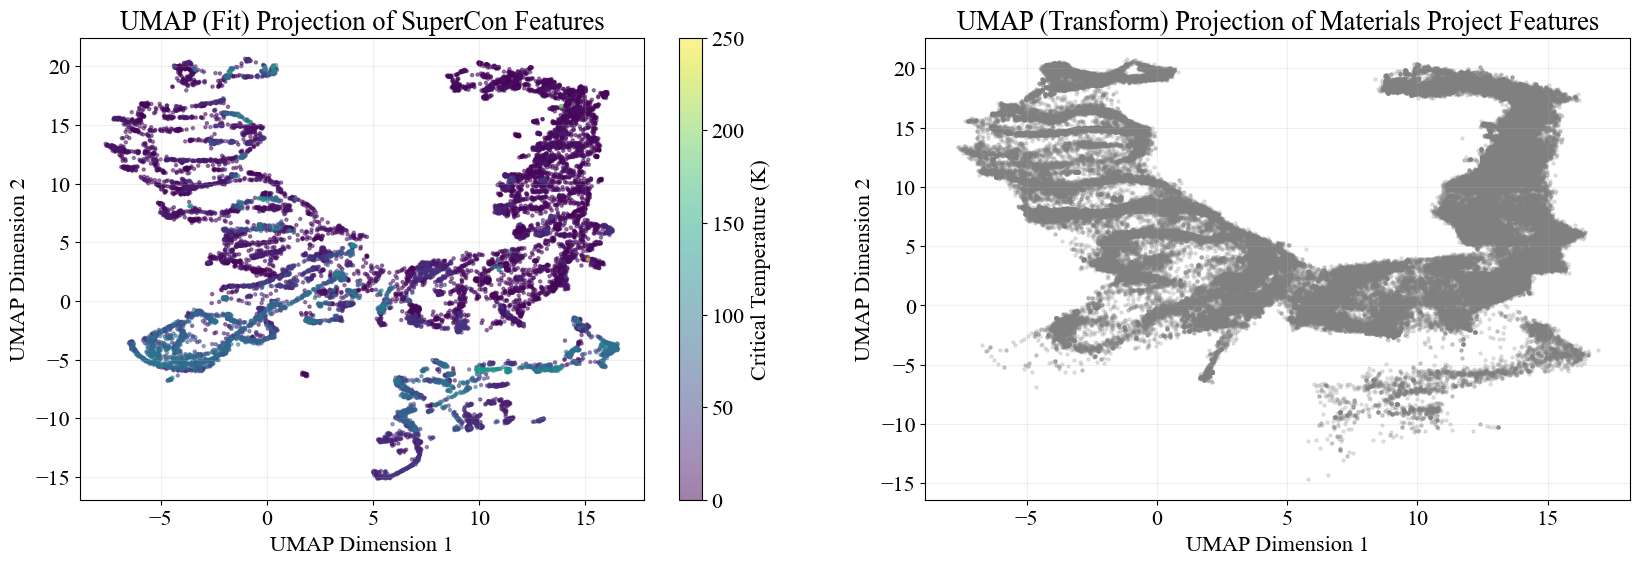

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
ax = ax.flatten()

pl1=ax[0].scatter(emb_SC_opt[:, 0], emb_SC_opt[:, 1], s=5, c = tc, alpha=0.5)
ax[1].scatter(emb_MP_opt[:, 0], emb_MP_opt[:, 1], s=5, c = 'gray', alpha=0.2)
plt.colorbar(pl1,label='Critical Temperature (K)', cmap = 'jet')
ax[0].set_title('UMAP (Fit) Projection of SuperCon Features')
ax[1].set_title('UMAP (Transform) Projection of Materials Project Features')
ax[0].set_xlabel('UMAP Dimension 1')
ax[0].set_ylabel('UMAP Dimension 2')
ax[1].set_xlabel('UMAP Dimension 1')
ax[1].set_ylabel('UMAP Dimension 2')
# plt.tight_layout()

In [39]:
mask_Cu = np.array(['Cu' in str(s) for s in chem_SC])
mask_Al = np.array(['Al' in str(s) for s in chem_SC])
mask_O = np.array(['O' in str(s) for s in chem_SC])
mask_Fe = np.array(['Fe' in str(s) for s in chem_SC])
mask_Nb = np.array(['Nb' in str(s) for s in chem_SC])
mask_CuO =  (mask_Cu) & (mask_O)
mask_MgB = np.array(['MgB' in str(s) for s in chem_SC])


mask_Cu_mp = np.array(['Cu' in str(s) for s in chem_MP])
mask_Al_mp = np.array(['Al' in str(s) for s in chem_MP])
mask_O_mp = np.array(['O' in str(s) for s in chem_MP])
mask_Fe_mp = np.array(['Fe' in str(s) for s in chem_MP])
mask_Nb_mp = np.array(['Nb' in str(s) for s in chem_MP])
mask_MgB_mp = np.array(['MgB' in str(s) for s in chem_MP])

emb_CuO = emb_SC_opt[(mask_Cu) & (mask_O)]
emb_Al = emb_SC_opt[mask_Al]
emb_Fe = emb_SC_opt[mask_Fe]
emb_Nb = emb_SC_opt[mask_Nb]

emb2_CuO = emb_MP_opt[(mask_Cu_mp) & (mask_O_mp)]
emb2_Al = emb_MP_opt[mask_Al_mp]
emb2_Fe = emb_MP_opt[mask_Fe_mp]
emb2_Nb = emb_MP_opt[mask_Nb_mp]

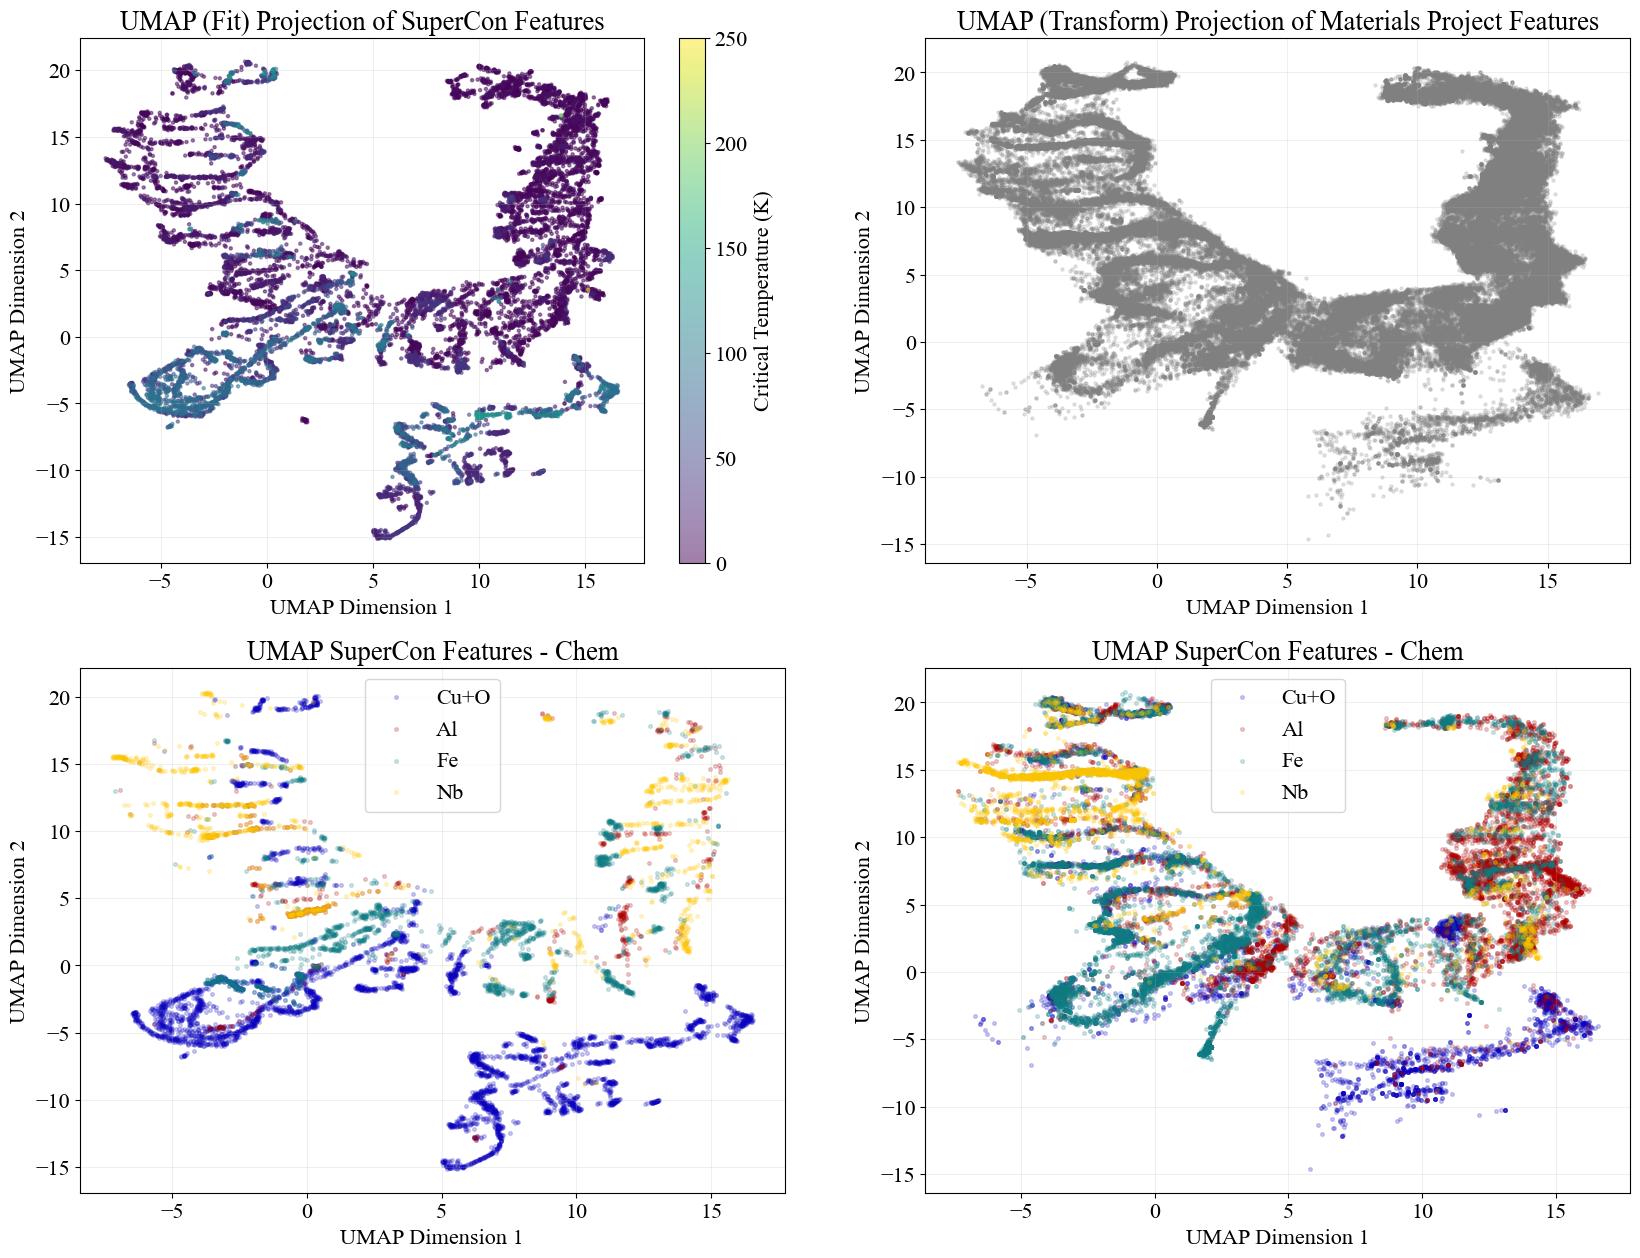

In [37]:
fig, ax = plt.subplots(2, 2, figsize=(20, 15))
ax = ax.flatten()

pl1=ax[0].scatter(emb_SC_opt[:, 0], emb_SC_opt[:, 1], s=5, c = tc, alpha=0.5)
ax[1].scatter(emb_MP_opt[:, 0], emb_MP_opt[:, 1], s=5, c = 'gray', alpha=0.2)
plt.colorbar(pl1,label='Critical Temperature (K)', cmap = 'jet')
ax[0].set_title('UMAP (Fit) Projection of SuperCon Features')
ax[1].set_title('UMAP (Transform) Projection of Materials Project Features')
ax[0].set_xlabel('UMAP Dimension 1')
ax[0].set_ylabel('UMAP Dimension 2')
ax[1].set_xlabel('UMAP Dimension 1')
ax[1].set_ylabel('UMAP Dimension 2')
# plt.tight_layout()

ax[2].scatter(emb_CuO[:, 0], emb_CuO[:, 1], s=7, alpha=0.2, label='Cu+O')
ax[2].scatter(emb_Al[:, 0], emb_Al[:, 1], s=7, alpha=0.2, label='Al')
ax[2].scatter(emb_Fe[:, 0], emb_Fe[:, 1], s=7, alpha=0.2, label='Fe')
ax[2].scatter(emb_Nb[:, 0], emb_Nb[:, 1], s=7, alpha=0.2, label='Nb')

ax[2].set_title('UMAP SuperCon Features - Chem')
ax[2].set_xlabel('UMAP Dimension 1')
ax[2].set_ylabel('UMAP Dimension 2')
ax[2].legend()

ax[3].scatter(emb2_CuO[:, 0], emb2_CuO[:, 1], s=7, alpha=0.2, label='Cu+O')
ax[3].scatter(emb2_Al[:, 0], emb2_Al[:, 1], s=7, alpha=0.2, label='Al')
ax[3].scatter(emb2_Fe[:, 0], emb2_Fe[:, 1], s=7, alpha=0.2, label='Fe')
ax[3].scatter(emb2_Nb[:, 0], emb2_Nb[:, 1], s=7, alpha=0.2, label='Nb')

ax[3].set_title('UMAP SuperCon Features - Chem')
ax[3].set_xlabel('UMAP Dimension 1')
ax[3].set_ylabel('UMAP Dimension 2')
ax[3].legend()


plt.show()

## With suggested clusters

In [40]:
labels = np.zeros(len(data_array), dtype=int)
labels[mask_CuO] = 1
labels[mask_Fe]   = 2
labels[mask_Nb]   = 3
labels[mask_MgB]  = 4
# 0 = other

In [42]:
import optuna
import umap
import numpy as np
from sklearn.metrics import silhouette_score

feature_names = data_SC.columns.tolist()  # your 147 features
data_array = data_SC.values

def objective(trial):
    n_features = trial.suggest_int("n_features", 5, 50)
    # For each feature, suggest whether to include it or not
    weights = [trial.suggest_float(f"w_{i}", 0.0, 1.0) for i in range(len(feature_names))]
    selected = sorted(range(len(feature_names)), key=lambda i: -weights[i])[:n_features]
    
    # Need at least a few features
    if len(selected) < 5 or len(selected) > 25:
        return -1.0
    
    X = data_array[:, selected]
    
    reducer = umap.UMAP(
        n_neighbors=103,  # your current params, or use best from previous study
        min_dist=0.5,
        n_components=2,
        random_state=42
    )
    embedding = reducer.fit_transform(X)
    
    score = silhouette_score(embedding, labels, sample_size=5000, random_state=42)
    return score

study_features = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_features.optimize(objective, n_trials=50, show_progress_bar=True)

# Get the selected features from best trial
best_trial = study_features.best_trial
selected_features = [
    feature_names[i] for i in range(len(feature_names))
    if best_trial.params[f"feature_{i}"]
]

print(f"Selected {len(selected_features)} features:")
print(selected_features)

[I 2026-05-25 14:10:52,647] A new study created in memory with name: no-name-805ce1ac-7c7a-42dd-90a9-ce4e1a451517
  0%|          | 0/50 [00:00<?, ?it/s]/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Best trial: 0. Best value: 0.0516205:   2%|▏         | 1/50 [00:11<09:04, 11.11s/it]/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-25 14:11:03,759] Trial 0 finished with value: 0.05162053182721138 and parameters: {'n_features': 22, 'w_0': 0.9507143064099162, 'w_1': 0.7319939418114051, 'w_2': 0.5986584841970366, 'w_3': 0.15601864044243652, 'w_4': 0.15599452033620265, 'w_5': 0.05808361216819946, 'w_6': 0.8661761457749352, 'w_7': 0.6011150117432088, 'w_8': 0.7080725777960455, 'w_9': 0.020584494295802447, 'w_10': 0.9699098521619943, 'w_11': 0.8324426408004217, 'w_12': 0.21233911067827616, 'w_13': 0.18182496720710062, 'w_14': 0.18340450985343382, 'w_15': 0.3042422429595377, 'w_16': 0.5247564316322378, 'w_17': 0.43194501864211576, 'w_18': 0.2912291401980419, 'w_19': 0.6118528947223795, 'w_20': 0.13949386065204183, 'w_21': 0.29214464853521815, 'w_22': 0.3663618432936917, 'w_23': 0.45606998421703593, 'w_24': 0.7851759613930136, 'w_25': 0.19967378215835974, 'w_26': 0.5142344384136116, 'w_27': 0.5924145688620425, 'w_28': 0.046450412719997725, 'w_29': 0.6075448519014384, 'w_30': 0.17052412368729153, 'w_31': 0.0650

Best trial: 0. Best value: 0.0516205:   6%|▌         | 3/50 [00:22<08:51, 11.31s/it]/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-25 14:11:15,210] Trial 1 finished with value: -0.04072833061218262 and parameters: {'n_features': 7, 'w_0': 0.27864646423661144, 'w_1': 0.9082658859666537, 'w_2': 0.23956189066697242, 'w_3': 0.1448948720912231, 'w_4': 0.489452760277563, 'w_5': 0.9856504541106007, 'w_6': 0.2420552715115004, 'w_7': 0.6721355474058786, 'w_8': 0.7616196153287176, 'w_9': 0.23763754399239967, 'w_10': 0.7282163486118596, 'w_11': 0.3677831327192532, 'w_12': 0.6323058305935795, 'w_13': 0.6335297107608947, 'w_14': 0.5357746840747585, 'w_15': 0.0902897700544083, 'w_16': 0.835302495589238, 'w_17': 0.32078006497173583, 'w_18': 0.18651851039985423, 'w_19': 0.040775141554763916, 'w_20': 0.5908929431882418, 'w_21': 0.6775643618422824, 'w_22': 0.016587828927856152, 'w_23': 0.512093058299281, 'w_24': 0.22649577519793795, 'w_25': 0.6451727904094499, 'w_26': 0.17436642900499144, 'w_27': 0.690937738102466, 'w_28': 0.3867353463005374, 'w_29': 0.9367299887367345, 'w_30': 0.13752094414599325, 'w_31': 0.341066351050

Best trial: 0. Best value: 0.0516205:  10%|█         | 5/50 [00:33<04:22,  5.84s/it]/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

Best trial: 32. Best value: 0.0835106:  98%|█████████▊| 49/50 [06:57<00:09,  9.04s/it]/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-25 14:17:50,020] Trial 48 finished with value: 0.04647824913263321 and parameters: {'n_features': 9, 'w_0': 0.2626571203567749, 'w_1': 0.1535616757361931, 'w_2': 0.8171315007216384, 'w_3': 0.5304250406581426, 'w_4': 0.9357067270092909, 'w_5': 0.30109384883474855, 'w_6': 0.5064162449125116, 'w_7': 0.18608720691942443, 'w_8': 0.3019263520878368, 'w_9': 0.4860854862367524, 'w_10': 0.36204722127495653, 'w_11': 0.28056225683826497, 'w_12': 0.34253571387845294, 'w_13': 0.1924269639963932, 'w_14': 0.21851966180647653, 'w_15': 0.014726171020550405, 'w_16': 0.9599146072134355, 'w_17': 0.22602774741611847, 'w_18': 0.6130282138818557, 'w_19': 0.0005409572911897172, 'w_20': 0.6025795373921066, 'w_21': 0.9579378605557823, 'w_22': 0.7015795904556852, 'w_23': 0.6502338503345046, 'w_24': 0.9267537865106423, 'w_25': 0.9662684938072992, 'w_26': 0.9570349013622691, 'w_27': 0.5073785231524855, 'w_28': 0.039360771177322854, 'w_29': 0.6407789551102354, 'w_30': 0.270916767963416, 'w_31': 0.9713733

Best trial: 32. Best value: 0.0835106: 100%|██████████| 50/50 [07:09<00:00,  8.59s/it]

[I 2026-05-25 14:18:02,004] Trial 49 finished with value: 0.06707441061735153 and parameters: {'n_features': 20, 'w_0': 0.8854776991017748, 'w_1': 0.648416174520235, 'w_2': 0.3425458475148331, 'w_3': 0.6625818182886831, 'w_4': 0.8727484321566464, 'w_5': 0.3984749934799877, 'w_6': 0.9956479203070747, 'w_7': 0.2946587772182994, 'w_8': 0.6041892190304168, 'w_9': 0.709200403231921, 'w_10': 0.9998440686854141, 'w_11': 0.40203925822621733, 'w_12': 0.6488584283878203, 'w_13': 0.33176369904904773, 'w_14': 0.9372659944445425, 'w_15': 0.7532283623017314, 'w_16': 0.18799153304682362, 'w_17': 0.8760728954327374, 'w_18': 0.9208649940253306, 'w_19': 0.38874416952388813, 'w_20': 0.7570928833821136, 'w_21': 0.8215771361586851, 'w_22': 0.9581816898492289, 'w_23': 0.3862067979878788, 'w_24': 0.46093842045808914, 'w_25': 0.34195379721491215, 'w_26': 0.04764668066162858, 'w_27': 0.29255832717906294, 'w_28': 0.6429442564061072, 'w_29': 0.5803045936259681, 'w_30': 0.3551733487708796, 'w_31': 0.7582153087702

KeyError: 'feature_0'

In [43]:
best_trial_mask = study_features.best_trial

n_features_m = best_trial_mask.params["n_features"]
weights_m = [best_trial_mask.params[f"w_{i}"] for i in range(len(feature_names))]
selected_indices_m = sorted(range(len(feature_names)), key=lambda i: -weights_m[i])[:n_features_m]

selected_features_m = [feature_names[i] for i in selected_indices_m]

print(f"Selected {len(selected_features_m)} features:")
print(selected_features_m)

Selected 25 features:
['MagpieData avg_dev MeltingT', 'MagpieData mode Row', 'MagpieData mean Number', 'avg d valence electrons', 'MagpieData mode GSmagmom', 'MagpieData maximum NdValence', 'MagpieData mean MeltingT', 'MagpieData minimum GSmagmom', 'MagpieData range NfValence', 'MagpieData range CovalentRadius', 'MagpieData maximum NsValence', 'MagpieData range NpValence', 'MagpieData range NsUnfilled', 'MagpieData mode NsValence', 'MagpieData mean SpaceGroupNumber', 'MagpieData mode MendeleevNumber', 'MagpieData maximum NsUnfilled', 'MagpieData minimum NpValence', 'MagpieData minimum NfValence', 'MagpieData mode NfUnfilled', 'MagpieData avg_dev Row', 'MagpieData range Row', 'MagpieData range NValence', 'MagpieData maximum NdUnfilled', '10-norm']


<Axes: >

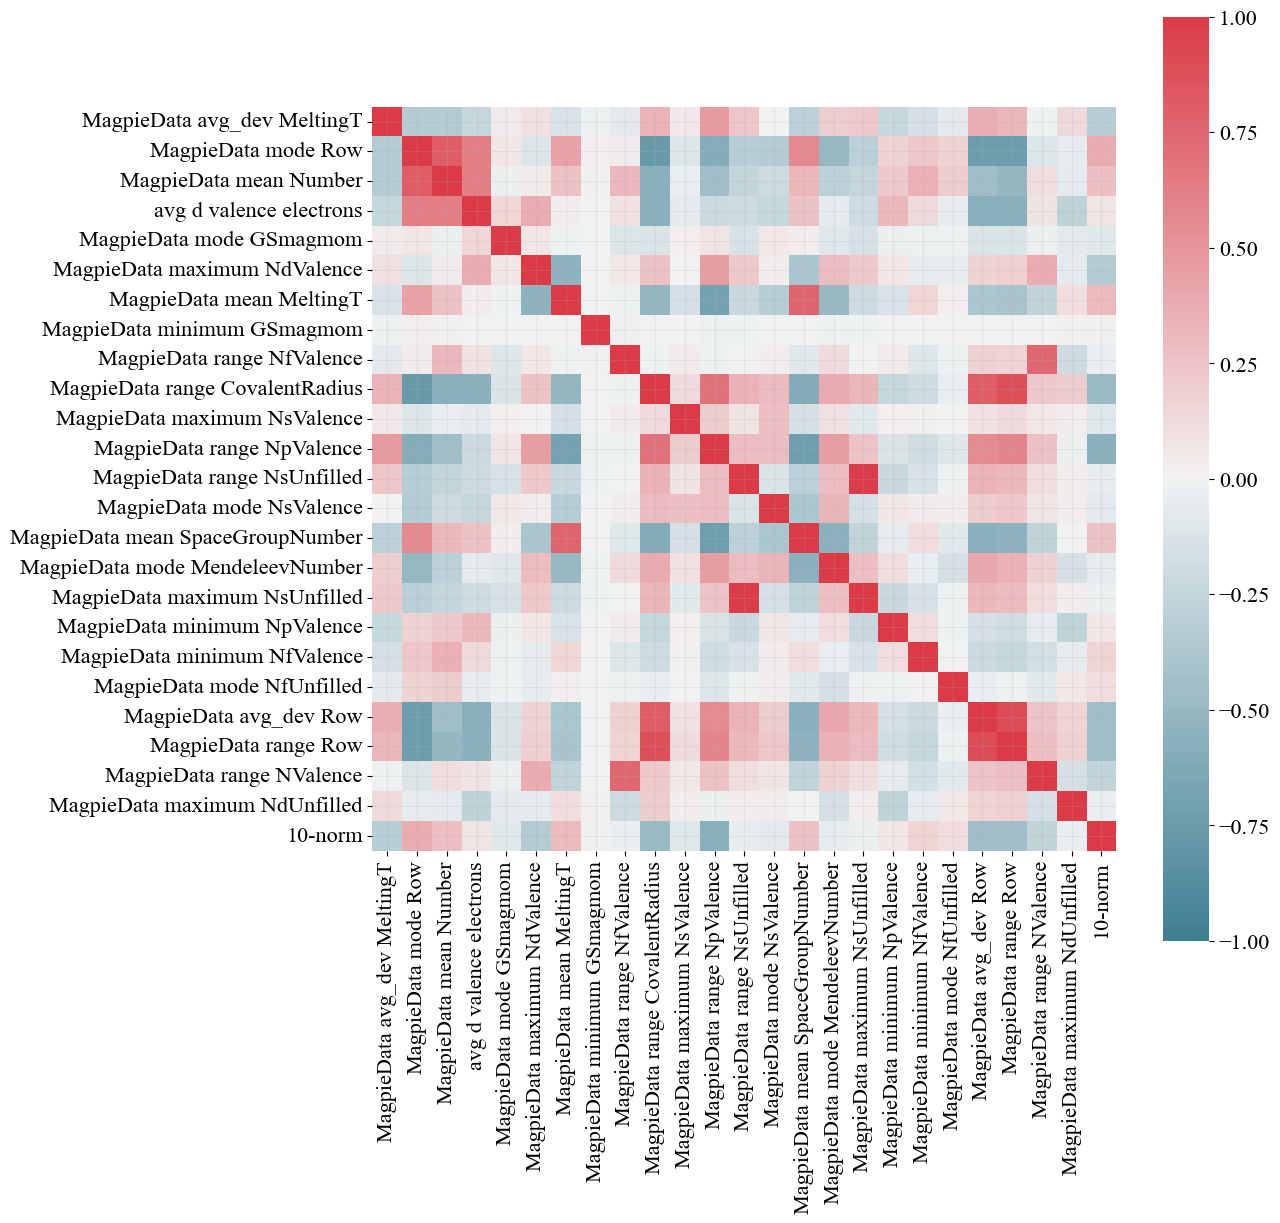

In [45]:
data_SC_redm = data_SC[selected_features_m]
data_MP_redm = data_MP[selected_features_m]

plt.figure(figsize=(12,12))
sns.heatmap(data_SC_redm.corr(), mask=np.zeros_like(data_SC_redm.corr(), dtype=np.bool),
            cmap=sns.diverging_palette(220, 10, as_cmap=True), vmin=-1.0, vmax=1.0,
            square=True)

In [54]:
count_non = 0

for k in selected_features_m:
    if np.isin(k, selected_features)==False:
        print(k, 'is not in the non-masked one')
        count_non +=1

print(count_non, 'out of', len(selected_features_m))

MagpieData avg_dev MeltingT is not in the non-masked one
MagpieData mean Number is not in the non-masked one
MagpieData mode GSmagmom is not in the non-masked one
MagpieData mean MeltingT is not in the non-masked one
MagpieData minimum GSmagmom is not in the non-masked one
MagpieData range NfValence is not in the non-masked one
MagpieData maximum NsValence is not in the non-masked one
MagpieData range NsUnfilled is not in the non-masked one
MagpieData mode NsValence is not in the non-masked one
MagpieData mode MendeleevNumber is not in the non-masked one
MagpieData maximum NsUnfilled is not in the non-masked one
MagpieData minimum NfValence is not in the non-masked one
MagpieData mode NfUnfilled is not in the non-masked one
MagpieData avg_dev Row is not in the non-masked one
MagpieData range Row is not in the non-masked one
MagpieData range NValence is not in the non-masked one
16 out of 25


In [56]:
reducerm = umap.UMAP(n_neighbors=103, min_dist=0.5, n_components=2, random_state=42)
emb_SC_optm = reducerm.fit_transform(data_SC_redm)
emb_MP_optm = reducerm.transform(data_MP_redm)

/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [117]:
mask_Cu = np.array(['Cu' in str(s) for s in chem_SC])
mask_Al = np.array(['Al' in str(s) for s in chem_SC])
mask_O = np.array(['O' in str(s) for s in chem_SC])
mask_Fe = np.array(['Fe' in str(s) for s in chem_SC])
mask_Nb = np.array(['Nb' in str(s) for s in chem_SC])
mask_CuO =  (mask_Cu) & (mask_O)
mask_MgB = (np.array(['Mg' in str(s) for s in chem_SC]) & (np.array(['B' in str(s) for s in chem_SC])))


mask_Cu_mp = np.array(['Cu' in str(s) for s in chem_MP])
mask_Al_mp = np.array(['Al' in str(s) for s in chem_MP])
mask_O_mp = np.array(['O' in str(s) for s in chem_MP])
mask_Fe_mp = np.array(['Fe' in str(s) for s in chem_MP])
mask_Nb_mp = np.array(['Nb' in str(s) for s in chem_MP])
mask_MgB_mp = np.array(['MgB' in str(s) for s in chem_MP])

emb_CuO = emb_SC_optm[(mask_Cu) & (mask_O)]
emb_Al = emb_SC_optm[mask_Al]
emb_Fe = emb_SC_optm[mask_Fe]
emb_Nb = emb_SC_optm[mask_Nb]

emb2_CuO = emb_MP_optm[(mask_Cu_mp) & (mask_O_mp)]
emb2_Al = emb_MP_optm[mask_Al_mp]
emb2_Fe = emb_MP_optm[mask_Fe_mp]
emb2_Nb = emb_MP_optm[mask_Nb_mp]

NameError: name 'emb_MgB' is not defined

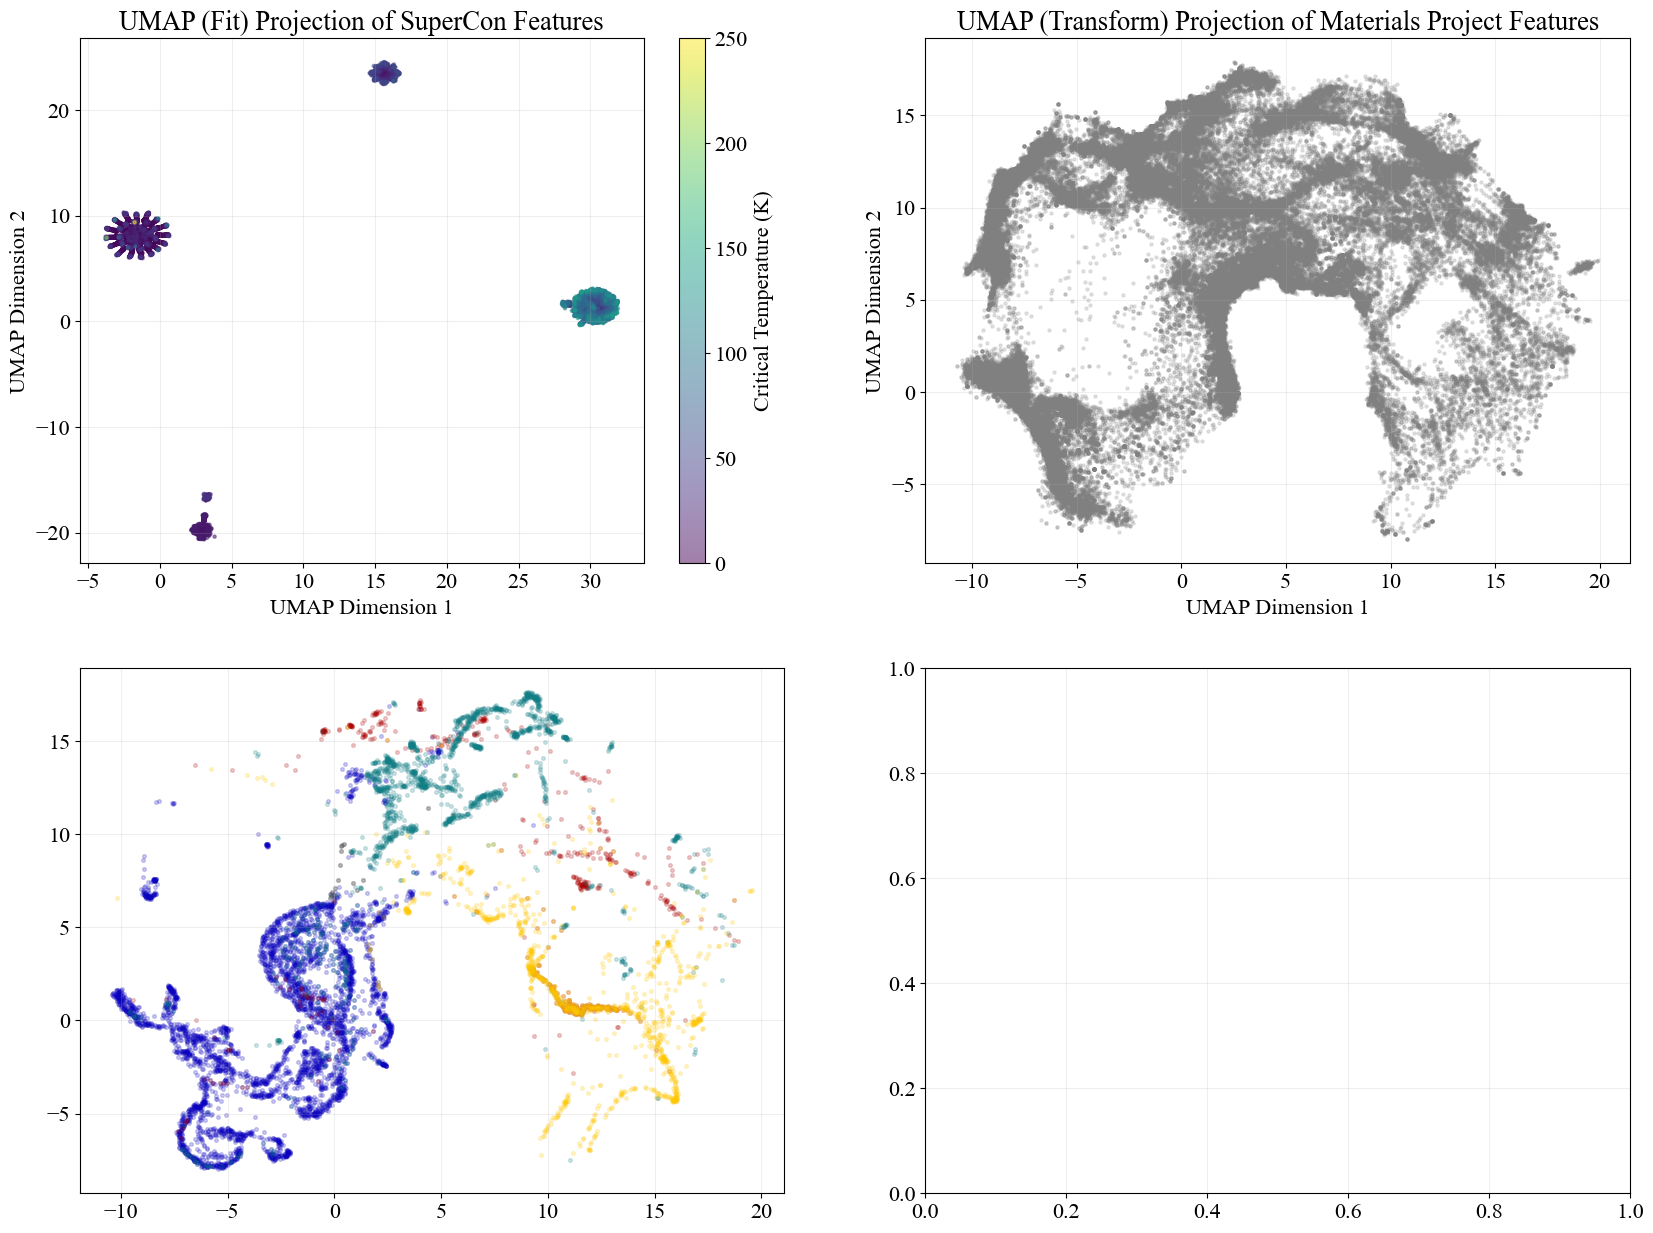

In [111]:
fig, ax = plt.subplots(2, 2, figsize=(20, 15))
ax = ax.flatten()

pl1=ax[0].scatter(emb_SC_optm[:, 0], emb_SC_optm[:, 1], s=5, c = tc, alpha=0.5)
ax[1].scatter(emb_MP_optm[:, 0], emb_MP_optm[:, 1], s=5, c = 'gray', alpha=0.2)
plt.colorbar(pl1,label='Critical Temperature (K)', cmap = 'jet')
ax[0].set_title('UMAP (Fit) Projection of SuperCon Features')
ax[1].set_title('UMAP (Transform) Projection of Materials Project Features')
ax[0].set_xlabel('UMAP Dimension 1')
ax[0].set_ylabel('UMAP Dimension 2')
ax[1].set_xlabel('UMAP Dimension 1')
ax[1].set_ylabel('UMAP Dimension 2')
# plt.tight_layout()

ax[2].scatter(emb_CuO[:, 0], emb_CuO[:, 1], s=7, alpha=0.2, label='Cu+O')
ax[2].scatter(emb_Al[:, 0], emb_Al[:, 1], s=7, alpha=0.2, label='Al')
ax[2].scatter(emb_Fe[:, 0], emb_Fe[:, 1], s=7, alpha=0.2, label='Fe')
ax[2].scatter(emb_Nb[:, 0], emb_Nb[:, 1], s=7, alpha=0.2, label='Nb')
ax[2].scatter(emb_MgB[:, 0], emb_MgB[:, 1], s=7, alpha=0.2, label='Nb')

ax[2].set_title('UMAP SuperCon Features - Chem')
ax[2].set_xlabel('UMAP Dimension 1')
ax[2].set_ylabel('UMAP Dimension 2')
ax[2].legend()

ax[3].scatter(emb2_CuO[:, 0], emb2_CuO[:, 1], s=7, alpha=0.2, label='Cu+O')
ax[3].scatter(emb2_Al[:, 0], emb2_Al[:, 1], s=7, alpha=0.2, label='Al')
ax[3].scatter(emb2_Fe[:, 0], emb2_Fe[:, 1], s=7, alpha=0.2, label='Fe')
ax[3].scatter(emb2_Nb[:, 0], emb2_Nb[:, 1], s=7, alpha=0.2, label='Nb')


ax[3].set_title('UMAP SuperCon Features - Chem')
ax[3].set_xlabel('UMAP Dimension 1')
ax[3].set_ylabel('UMAP Dimension 2')
ax[3].legend()


plt.show()

In [84]:
masks = np.array([mask_CuO, mask_Nb, mask_Al, mask_Fe, mask_MgB])

stuff = np.sum(masks, axis=0)

print(max(stuff))
print(np.count_nonzero(stuff))

print('No more than 2 catagories at the same time')

2
7687
No more than 2 catagories at the same time


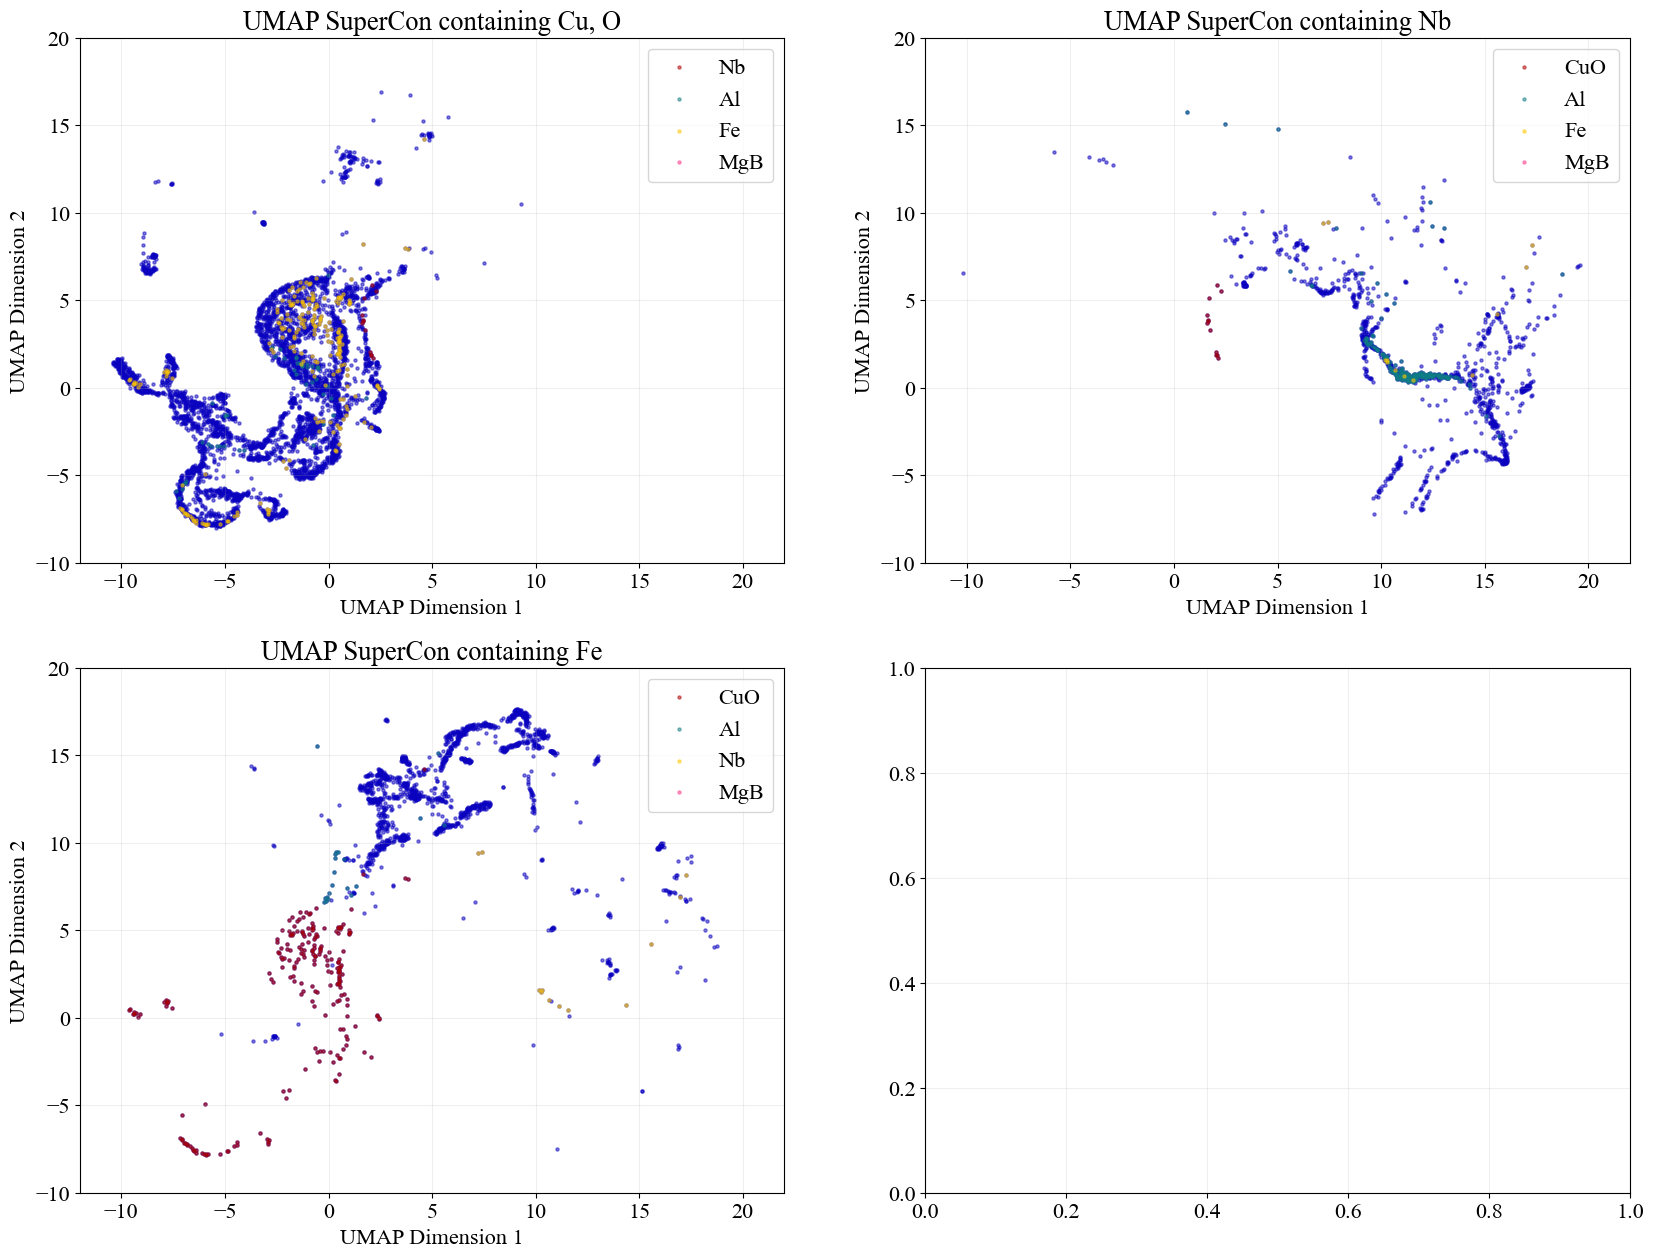

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(20, 15))
ax = ax.flatten()

ax[0].scatter(emb_SC_optm[(mask_CuO) & (mask_CuO)][:, 0], emb_SC_optm[(mask_CuO) & (mask_CuO)][:, 1], s=5, alpha=0.5)
ax[0].scatter(emb_SC_optm[(mask_Nb) & (mask_CuO)][:, 0], emb_SC_optm[(mask_Nb) & (mask_CuO)][:, 1], s=5, alpha=0.5, label='Nb')
ax[0].scatter(emb_SC_optm[(mask_Al) & (mask_CuO)][:, 0], emb_SC_optm[(mask_Al) & (mask_CuO)][:, 1], s=5, alpha=0.5, label='Al')
ax[0].scatter(emb_SC_optm[(mask_Fe) & (mask_CuO)][:, 0], emb_SC_optm[(mask_Fe) & (mask_CuO)][:, 1], s=5, alpha=0.5, label='Fe')
ax[0].scatter(emb_SC_optm[(mask_MgB) & (mask_CuO)][:, 0], emb_SC_optm[(mask_MgB) & (mask_CuO)][:, 1], s=5, alpha=0.5, label='MgB')

ax[0].set_title('UMAP SuperCon containing Cu, O')
ax[0].legend()
ax[0].set_xlim(-12,22)
ax[0].set_ylim(-10,20)

ax[0].set_xlabel('UMAP Dimension 1')
ax[0].set_ylabel('UMAP Dimension 2')


ax[1].scatter(emb_SC_optm[(mask_Nb) & (mask_Nb)][:, 0], emb_SC_optm[(mask_Nb) & (mask_Nb)][:, 1], s=5, alpha=0.5)
ax[1].scatter(emb_SC_optm[(mask_CuO) & (mask_Nb)][:, 0], emb_SC_optm[(mask_CuO) & (mask_Nb)][:, 1], s=5, alpha=0.5, label='Cu,O')
ax[1].scatter(emb_SC_optm[(mask_Al) & (mask_Nb)][:, 0], emb_SC_optm[(mask_Al) & (mask_Nb)][:, 1], s=5, alpha=0.5, label='Al')
ax[1].scatter(emb_SC_optm[(mask_Fe) & (mask_Nb)][:, 0], emb_SC_optm[(mask_Fe) & (mask_Nb)][:, 1], s=5, alpha=0.5, label='Fe')
ax[1].scatter(emb_SC_optm[(mask_MgB) & (mask_Nb)][:, 0], emb_SC_optm[(mask_MgB) & (mask_Nb)][:, 1], s=5, alpha=0.5, label='MgB')

ax[1].set_title('UMAP SuperCon containing Nb')
ax[1].legend()
ax[1].set_xlim(-12,22)
ax[1].set_ylim(-10,20)

ax[1].set_xlabel('UMAP Dimension 1')
ax[1].set_ylabel('UMAP Dimension 2')


ax[2].scatter(emb_SC_optm[(mask_Fe) & (mask_Fe)][:, 0], emb_SC_optm[(mask_Fe) & (mask_Fe)][:, 1], s=5, alpha=0.5)
ax[2].scatter(emb_SC_optm[(mask_CuO) & (mask_Fe)][:, 0], emb_SC_optm[(mask_CuO) & (mask_Fe)][:, 1], s=5, alpha=0.5, label='Cu,O')
ax[2].scatter(emb_SC_optm[(mask_Al) & (mask_Fe)][:, 0], emb_SC_optm[(mask_Al) & (mask_Fe)][:, 1], s=5, alpha=0.5, label='Al')
ax[2].scatter(emb_SC_optm[(mask_Nb) & (mask_Fe)][:, 0], emb_SC_optm[(mask_Nb) & (mask_Fe)][:, 1], s=5, alpha=0.5, label='Nb')
ax[2].scatter(emb_SC_optm[(mask_MgB) & (mask_Fe)][:, 0], emb_SC_optm[(mask_MgB) & (mask_Fe)][:, 1], s=5, alpha=0.5, label='MgB')

ax[2].set_title('UMAP SuperCon containing Fe')
ax[2].legend()
ax[2].set_xlim(-12,22)
ax[2].set_ylim(-10,20)

ax[2].set_xlabel('UMAP Dimension 1')
ax[2].set_ylabel('UMAP Dimension 2')

ax[3].scatter(emb_SC_optm[:, 0], emb_SC_optm[:, 1], s=5, alpha=0.5)
ax[3].set_title('UMAP SuperCon')
ax[3].legend()
ax[3].set_xlim(-12,22)
ax[3].set_ylim(-10,20)

ax[3].set_xlabel('UMAP Dimension 1')
ax[3].set_ylabel('UMAP Dimension 2')


plt.show()

In [118]:
data_comp = pd.DataFrame({
    'CuO': mask_CuO,
    'Fe': mask_Fe,
    'Nb': mask_Nb,
    'Al': mask_Al,
    'MgB': mask_MgB
})

In [151]:
import re
from collections import Counter

# Find all unique elements across all strings
all_elements = []
for s in chem_SC:
    all_elements.extend(re.findall(r'[A-Z][a-z]?', s))

unique_elements = sorted(set(all_elements))
print(unique_elements)  # see what you've got

# Then make a mask for each element
masks = {}
for el in unique_elements:
    pattern = el + '(?![a-z])'  # e.g. 'H(?![a-z])' matches H but not Ho
    masks[el] = np.array([bool(re.search(pattern, s)) for s in chem_SC])



df_all_el = pd.DataFrame(masks)

# df_all_el['tc'] = tc_SC

['Ag', 'Al', 'Am', 'As', 'Au', 'B', 'Ba', 'Be', 'Bi', 'Br', 'C', 'Ca', 'Cd', 'Ce', 'Cl', 'Co', 'Cr', 'Cs', 'Cu', 'Dy', 'Er', 'Eu', 'F', 'Fe', 'Ga', 'Gd', 'Ge', 'H', 'Hf', 'Hg', 'Ho', 'I', 'In', 'Ir', 'K', 'La', 'Li', 'Lu', 'Mg', 'Mn', 'Mo', 'N', 'Na', 'Nb', 'Nd', 'Ni', 'Np', 'O', 'Os', 'P', 'Pa', 'Pb', 'Pd', 'Pr', 'Pt', 'Pu', 'Rb', 'Re', 'Rh', 'Ru', 'S', 'Sb', 'Sc', 'Se', 'Si', 'Sm', 'Sn', 'Sr', 'Ta', 'Tb', 'Tc', 'Te', 'Th', 'Ti', 'Tl', 'Tm', 'U', 'V', 'W', 'Y', 'Yb', 'Zn', 'Zr']


In [152]:
reducerm = umap.UMAP(n_neighbors=503, min_dist=0.9, n_components=2, random_state=42)
emb_SC_optm = reducerm.fit_transform(df_all_el)

/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


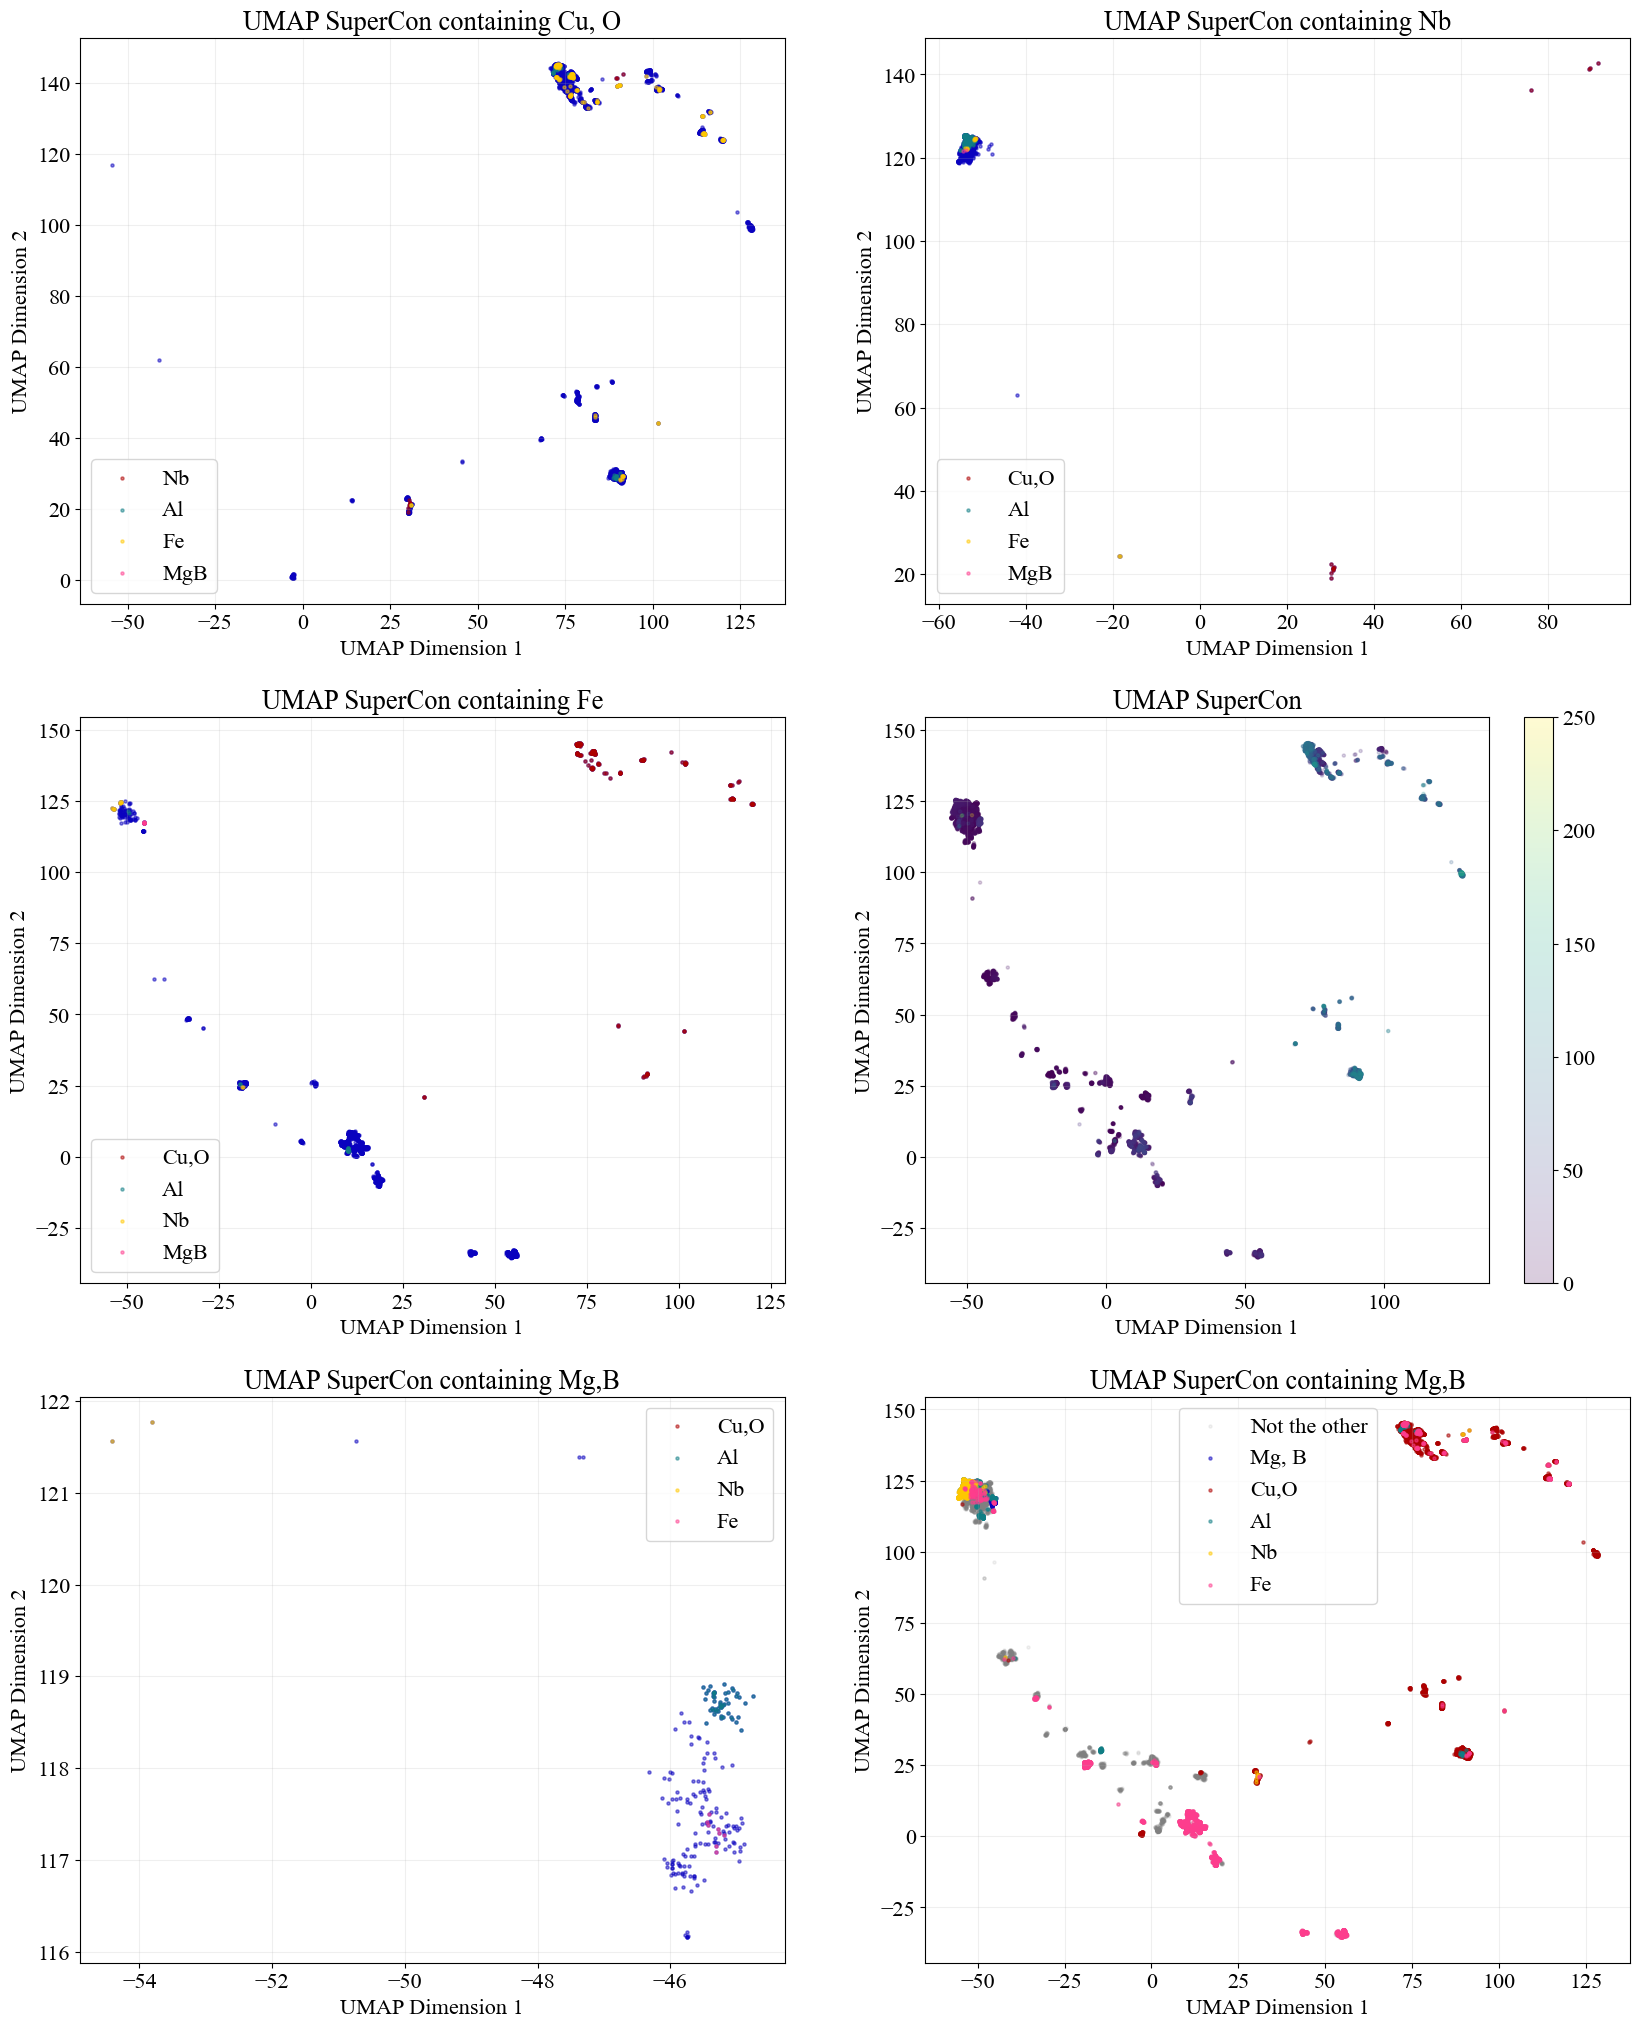

In [153]:
fig, ax = plt.subplots(3, 2, figsize=(20, 25))
ax = ax.flatten()

ax[0].scatter(emb_SC_optm[(mask_CuO) & (mask_CuO)][:, 0], emb_SC_optm[(mask_CuO) & (mask_CuO)][:, 1], s=5, alpha=0.5)
ax[0].scatter(emb_SC_optm[(mask_Nb) & (mask_CuO)][:, 0], emb_SC_optm[(mask_Nb) & (mask_CuO)][:, 1], s=5, alpha=0.5, label='Nb')
ax[0].scatter(emb_SC_optm[(mask_Al) & (mask_CuO)][:, 0], emb_SC_optm[(mask_Al) & (mask_CuO)][:, 1], s=5, alpha=0.5, label='Al')
ax[0].scatter(emb_SC_optm[(mask_Fe) & (mask_CuO)][:, 0], emb_SC_optm[(mask_Fe) & (mask_CuO)][:, 1], s=5, alpha=0.5, label='Fe')
ax[0].scatter(emb_SC_optm[(mask_MgB) & (mask_CuO)][:, 0], emb_SC_optm[(mask_MgB) & (mask_CuO)][:, 1], s=5, alpha=0.5, label='MgB')

ax[0].set_title('UMAP SuperCon containing Cu, O')
ax[0].legend()
# ax[0].set_xlim(-15,20)
# ax[0].set_ylim(-15,20)

ax[0].set_xlabel('UMAP Dimension 1')
ax[0].set_ylabel('UMAP Dimension 2')


ax[1].scatter(emb_SC_optm[(mask_Nb) & (mask_Nb)][:, 0], emb_SC_optm[(mask_Nb) & (mask_Nb)][:, 1], s=5, alpha=0.5)
ax[1].scatter(emb_SC_optm[(mask_CuO) & (mask_Nb)][:, 0], emb_SC_optm[(mask_CuO) & (mask_Nb)][:, 1], s=5, alpha=0.5, label='Cu,O')
ax[1].scatter(emb_SC_optm[(mask_Al) & (mask_Nb)][:, 0], emb_SC_optm[(mask_Al) & (mask_Nb)][:, 1], s=5, alpha=0.5, label='Al')
ax[1].scatter(emb_SC_optm[(mask_Fe) & (mask_Nb)][:, 0], emb_SC_optm[(mask_Fe) & (mask_Nb)][:, 1], s=5, alpha=0.5, label='Fe')
ax[1].scatter(emb_SC_optm[(mask_MgB) & (mask_Nb)][:, 0], emb_SC_optm[(mask_MgB) & (mask_Nb)][:, 1], s=5, alpha=0.5, label='MgB')

ax[1].set_title('UMAP SuperCon containing Nb')
ax[1].legend()
# ax[1].set_xlim(-15,20)
# ax[1].set_ylim(-15,20)


ax[1].set_xlabel('UMAP Dimension 1')
ax[1].set_ylabel('UMAP Dimension 2')


ax[2].scatter(emb_SC_optm[(mask_Fe) & (mask_Fe)][:, 0], emb_SC_optm[(mask_Fe) & (mask_Fe)][:, 1], s=5, alpha=0.5)
ax[2].scatter(emb_SC_optm[(mask_CuO) & (mask_Fe)][:, 0], emb_SC_optm[(mask_CuO) & (mask_Fe)][:, 1], s=5, alpha=0.5, label='Cu,O')
ax[2].scatter(emb_SC_optm[(mask_Al) & (mask_Fe)][:, 0], emb_SC_optm[(mask_Al) & (mask_Fe)][:, 1], s=5, alpha=0.5, label='Al')
ax[2].scatter(emb_SC_optm[(mask_Nb) & (mask_Fe)][:, 0], emb_SC_optm[(mask_Nb) & (mask_Fe)][:, 1], s=5, alpha=0.5, label='Nb')
ax[2].scatter(emb_SC_optm[(mask_MgB) & (mask_Fe)][:, 0], emb_SC_optm[(mask_MgB) & (mask_Fe)][:, 1], s=5, alpha=0.5, label='MgB')

ax[2].set_title('UMAP SuperCon containing Fe')
ax[2].legend()
# ax[2].set_xlim(-15,20)
# ax[2].set_ylim(-15,20)


ax[2].set_xlabel('UMAP Dimension 1')
ax[2].set_ylabel('UMAP Dimension 2')

pl1 = ax[3].scatter(emb_SC_optm[:, 0], emb_SC_optm[:, 1], s=5, c = tc, alpha=0.2)
plt.colorbar(pl1)
ax[3].set_title('UMAP SuperCon')
# ax[3].set_xlim(-15,20)
# ax[3].set_ylim(-15,20)


ax[3].set_xlabel('UMAP Dimension 1')
ax[3].set_ylabel('UMAP Dimension 2')

ax[4].scatter(emb_SC_optm[(mask_MgB) & (mask_MgB)][:, 0], emb_SC_optm[(mask_MgB) & (mask_MgB)][:, 1], s=5, alpha=0.5)
ax[4].scatter(emb_SC_optm[(mask_CuO) & (mask_MgB)][:, 0], emb_SC_optm[(mask_CuO) & (mask_MgB)][:, 1], s=5, alpha=0.5, label='Cu,O')
ax[4].scatter(emb_SC_optm[(mask_Al) & (mask_MgB)][:, 0], emb_SC_optm[(mask_Al) & (mask_MgB)][:, 1], s=5, alpha=0.5, label='Al')
ax[4].scatter(emb_SC_optm[(mask_Nb) & (mask_MgB)][:, 0], emb_SC_optm[(mask_Nb) & (mask_MgB)][:, 1], s=5, alpha=0.5, label='Nb')
ax[4].scatter(emb_SC_optm[(mask_Fe) & (mask_MgB)][:, 0], emb_SC_optm[(mask_Fe) & (mask_MgB)][:, 1], s=5, alpha=0.5, label='Fe')

ax[4].set_title('UMAP SuperCon containing Mg,B')
ax[4].legend()
# ax[4].set_xlim(-15,20)
# ax[4].set_ylim(-15,20)

ax[4].set_xlabel('UMAP Dimension 1')
ax[4].set_ylabel('UMAP Dimension 2')

ax[5].scatter(emb_SC_optm[:, 0], emb_SC_optm[:, 1], s=5, alpha=0.1, color='grey', label='Not the other')
ax[5].scatter(emb_SC_optm[(mask_MgB)][:, 0], emb_SC_optm[(mask_MgB)][:, 1], s=5, alpha=0.5, label='Mg, B')
ax[5].scatter(emb_SC_optm[(mask_CuO)][:, 0], emb_SC_optm[(mask_CuO)][:, 1], s=5, alpha=0.5, label='Cu,O')
ax[5].scatter(emb_SC_optm[(mask_Al)][:, 0], emb_SC_optm[(mask_Al)][:, 1], s=5, alpha=0.5, label='Al')
ax[5].scatter(emb_SC_optm[(mask_Nb)][:, 0], emb_SC_optm[(mask_Nb)][:, 1], s=5, alpha=0.5, label='Nb')
ax[5].scatter(emb_SC_optm[mask_Fe][:, 0], emb_SC_optm[mask_Fe][:, 1], s=5, alpha=0.5, label='Fe')
ax[5].set_title('UMAP SuperCon containing Mg,B')
ax[5].legend()

# ax[5].set_xlim(-15,20)
# ax[5].set_ylim(-15,20)

ax[5].set_xlabel('UMAP Dimension 1')
ax[5].set_ylabel('UMAP Dimension 2')


plt.show()

In [105]:
np.sum(['Cu' in s for s in chem_SC])

np.int64(4857)

In [136]:
df_all_el

,Ag,Al,Am,As,Au,B,Ba,Be,Bi,Br,...,Ti,Tl,Tm,U,V,W,Y,Yb,Zn,Zr
0,False,True,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13656,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13657,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13658,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13659,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
